# XGBoost y AdaBoost
En esta sección se implementan y evalúan modelos de ensamble basados en boosting
para predecir el rendimiento de combustible en millas por galón (MPG).

El conjunto de datos utilizado corresponde al dataset procesado previamente
en la sección de EDA, usando los datos sin escalar (train_raw / test_raw),
ya que los modelos basados en árboles no requieren normalización de variables.

Los modelos implementados son:
- AdaBoost (baseline y optimizado con GridSearch)
- XGBoost (baseline y optimizado con GridSearch)

El análisis exploratorio mostró relaciones no lineales entre las variables
weight, displacement, horsepower y cylinders con el MPG. Los modelos de
boosting son especialmente adecuados para capturar estos patrones, ya que
construyen iterativamente aprendices débiles (árboles de decisión) que
se combinan para formar un modelo fuerte.

AdaBoost ajusta los pesos de las observaciones mal predichas en cada ronda,
mientras que XGBoost optimiza una función de pérdida con regularización L1
y L2, lo que lo hace más robusto ante el sobreajuste.

La comparación se realiza utilizando las métricas:

- MAE (Mean Absolute Error)
- RMSE (Root Mean Squared Error)
- R² (Coeficiente de determinación)

# 1. Configuración del entorno 

In [21]:
import os, sys, random
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.ensemble import AdaBoostRegressor
from sklearn.tree import DecisionTreeRegressor
from sklearn.metrics import(
    mean_absolute_error, mean_squared_error, r2_score
)
from xgboost import XGBRegressor
from sklearn.compose import TransformedTargetRegressor

In [22]:
import os, random
import numpy as np

# Rutas
BASE         = r'C:\Users\vigil\OneDrive\Desktop\DiplomadoCienciasDatos\modulo 5\Proyecto_Predicción_MPG_Autos'
DATA         = os.path.join(BASE, 'data')       
PROJECT      = BASE                              
RANDOM_STATE = 42                               


random.seed(RANDOM_STATE)
np.random.seed(RANDOM_STATE)

os.makedirs(os.path.join(BASE, 'figures'), exist_ok=True)

print('Configuración lista')
print(f'   BASE        : {BASE}')
print(f'   DATA        : {DATA}')
print(f'   RANDOM_STATE: {RANDOM_STATE}')


Configuración lista
   BASE        : C:\Users\vigil\OneDrive\Desktop\DiplomadoCienciasDatos\modulo 5\Proyecto_Predicción_MPG_Autos
   DATA        : C:\Users\vigil\OneDrive\Desktop\DiplomadoCienciasDatos\modulo 5\Proyecto_Predicción_MPG_Autos\data
   RANDOM_STATE: 42


* Cargamos los splits ya preparados por el notebook de EDA: train_raw y test_raw: sin escalar.

In [23]:
# ── Carga de datos sin escalar 
# AdaBoost y XGBoost son modelos basados en árboles — no requieren
# escalado de variables. Usamos train_raw y test_raw directamente.

train = pd.read_csv(os.path.join(DATA, 'train_raw.csv'))
test  = pd.read_csv(os.path.join(DATA, 'test_raw.csv'))

X_train = train.drop('mpg', axis=1)
y_train = train['mpg']
X_test  = test.drop('mpg', axis=1)
y_test  = test['mpg']

print(f'Train: {X_train.shape} | Test: {X_test.shape}')
print(f'Columnas: {list(X_train.columns)}')


Train: (318, 8) | Test: (80, 8)
Columnas: ['displacement', 'cylinders', 'horsepower', 'weight', 'acceleration', 'model_year', 'origin_2', 'origin_3']


* Los modelos de árboles (AdaBoost, XGBoost) no necesitan escalado porque no calculan distancias ni penalizaciones, tal que, solo hacen divisiones binarias sobre los valores. Usar los datos sin escalar además facilita la interpretación de las importancias de variables en sus unidades originales.

+ **AdaBoost**

Queremos aproximar las millas por galón según características mecánicas de los autos.
+ queremos hacer que:

$$mpg = f(x_1, x_1, x_3, ... , x_n )$$

Definimos nuestro arbol base

In [24]:
arbol_base = DecisionTreeRegressor(max_depth=5, random_state = 42)

+ Definimos el modelo ADA

In [25]:
ADA = AdaBoostRegressor(
    estimator = arbol_base,
    n_estimators= 400,
    learning_rate = 0.07,
    random_state=42
)

+ Entrenamiento

In [26]:
Y_train_log = np.log1p(y_train)

In [27]:
ADA.fit(X_train, Y_train_log)

,"estimator estimator: object, default=NoneThe base estimator from which the boosted ensemble is built.If ``None``, then the base estimator is:class:`~sklearn.tree.DecisionTreeRegressor` initialized with`max_depth=3`... versionadded:: 1.2 `base_estimator` was renamed to `estimator`.",DecisionTreeR...ndom_state=42)
,"n_estimators n_estimators: int, default=50The maximum number of estimators at which boosting is terminated.In case of perfect fit, the learning procedure is stopped early.Values must be in the range `[1, inf)`.",400
,"learning_rate learning_rate: float, default=1.0Weight applied to each regressor at each boosting iteration. A higherlearning rate increases the contribution of each regressor. There isa trade-off between the `learning_rate` and `n_estimators` parameters.Values must be in the range `(0.0, inf)`.",0.07
,"random_state random_state: int, RandomState instance or None, default=NoneControls the random seed given at each `estimator` at eachboosting iteration.Thus, it is only used when `estimator` exposes a `random_state`.In addition, it controls the bootstrap of the weights used to train the`estimator` at each boosting iteration.Pass an int for reproducible output across multiple function calls.See :term:`Glossary <random_state>`.",42
,"loss loss: {'linear', 'square', 'exponential'}, default='linear'The loss function to use when updating the weights after eachboosting iteration.",'linear'
Name,Type,Value
estimator_ estimator_: estimatorThe base estimator from which the ensemble is grown... versionadded:: 1.2 `base_estimator_` was renamed to `estimator_`.,DecisionTreeRegressor,DecisionTreeR...ndom_state=42)
estimator_errors_ estimator_errors_: ndarray of floatsRegression error for each estimator in the boosted ensemble.,"ndarray[float64](400,)","[0.17,0.1 ,0.14,...,0.19,0.33,0.29]"
estimator_weights_ estimator_weights_: ndarray of floatsWeights for each estimator in the boosted ensemble.,"ndarray[float64](400,)","[0.11,0.15,0.13,...,0.1 ,0.05,0.06]"
estimators_ estimators_: list of regressorsThe collection of fitted sub-estimators.,list,"[DecisionTreeR...te=1608637542), DecisionTreeR...te=1899888366), DecisionTreeR...te=1041402894), DecisionTreeR...te=1163555517), ...]"
"feature_importances_ feature_importances_: ndarray of shape (n_features,)The impurity-based feature importances if supported by the``estimator`` (when based on decision trees).Warning: impurity-based feature importances can be misleading forhigh cardinality features (many unique values). See:func:`sklearn.inspection.permutation_importance` as an alternative.","ndarray[float64](8,)","[0.27,0.02,0.14,...,0.15,0. ,0. ]"


+ predicciones log

In [28]:
y_pred_log = ADA.predict(X_test)

+ Predicciones

In [29]:
y_pred_ada = np.expm1(y_pred_log)


+ Evaluaremos el modelo mediante **RME**, **LMSE** Y **MAE**

In [30]:
mse_ADA =mean_squared_error(
    y_test,
    y_pred_ada
)

rmse_ADA = np.sqrt(mse_ADA)

mae_ADA = mean_absolute_error(
    y_test,
    y_pred_ada
)

r2_ADA = r2_score(y_test, y_pred_ada)

print(f'RMSE : {rmse_ADA}')
print(f'MSE: {mse_ADA}')
print(f'MAE: {mae_ADA}')
print(f'R^2: {r2_ADA}')

RMSE : 2.421824301434835
MSE: 5.865232947020327
MAE: 1.7212890081780805
R^2: 0.8909127601168465


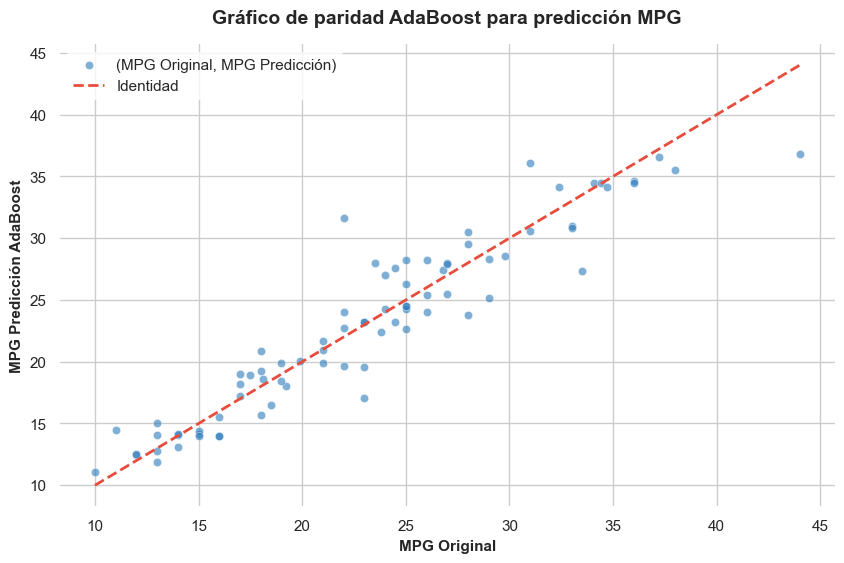

In [31]:
sns.set_theme(style='whitegrid', context = "notebook")
plt.figure(figsize=(10,6))
plt.scatter(y_test,
            y_pred_ada,
            color = '#2b7bba',
            alpha = 0.6,
            edgecolors = 'w',
            linewidths = 0.5,
            label = '(MPG Original, MPG Predicción)')
plt.plot(
       [y_test.min(), y_test.max()],
    [y_test.min(), y_test.max()],
       color = '#e74c3c',
       linestyle ='--',
       linewidth = 2,
       label = 'Identidad'

)
plt.title('Gráfico de paridad AdaBoost para predicción MPG', fontsize =14, fontweight ='bold',pad=15)
plt.xlabel('MPG Original', fontsize = 11, fontweight = 'semibold')
plt.ylabel('MPG Predicción AdaBoost', fontsize =11, fontweight = 'semibold')
plt.legend(frameon = True, facecolor='white', edgecolor='none')
sns.despine(left = True, bottom = True)
plt.savefig(f'{PROJECT}/figures/prediccion_ada_base.png',
            bbox_inches='tight')
plt.show()

+ **XGBOOST**

+ Definimos el modelo junto con sus hiperparámetros

In [32]:

XGB = XGBRegressor(
    n_estimators = 300,
    learning_rate = 0.05,

    min_child_weight = 5, 
    gamma = 0.1, 

    max_depth = 4,
    subsample = 0.8,
    colsample_bytree = 0.8,

    reg_alpha = 0.1,
    reg_lambda = 1.0,

    random_state = 42
                    )

+ Entrenamiento XGB "empírico".

In [33]:
XGB.fit(X_train, Y_train_log)

,"base_score base_score: float | typing.List[float] | NoneThe initial prediction score of all instances, global bias.",None
,booster,None
,"callbacks callbacks: typing.List[xgboost.callback.TrainingCallback] | NoneList of callback functions that are applied at end of each iteration.It is possible to use predefined callbacks by using:ref:`Callback API <callback_api>`... note:: States in callback are not preserved during training, which means callback objects can not be reused for multiple training sessions without reinitialization or deepcopy... code-block:: python for params in parameters_grid: # be sure to (re)initialize the callbacks before each run callbacks = [xgb.callback.LearningRateScheduler(custom_rates)] reg = xgboost.XGBRegressor(**params, callbacks=callbacks) reg.fit(X, y)",None
,colsample_bylevel colsample_bylevel: float | NoneSubsample ratio of columns for each level.,None
,colsample_bynode colsample_bynode: float | NoneSubsample ratio of columns for each split.,None
,colsample_bytree colsample_bytree: float | NoneSubsample ratio of columns when constructing each tree.,0.8
,"device device: str | None.. versionadded:: 2.0.0Device ordinal, available options are `cpu`, `cuda`, and `gpu`.",None
,"early_stopping_rounds early_stopping_rounds: int | None.. versionadded:: 1.6.0- Activates early stopping. Validation metric needs to improve at least once in every **early_stopping_rounds** round(s) to continue training. Requires at least one item in **eval_set** in :py:meth:`fit`.- If early stopping occurs, the model will have two additional attributes: :py:attr:`best_score` and :py:attr:`best_iteration`. These are used by the :py:meth:`predict` and :py:meth:`apply` methods to determine the optimal number of trees during inference. If users want to access the full model (including trees built after early stopping), they can specify the `iteration_range` in these inference methods. In addition, other utilities like model plotting can also use the entire model.- If you prefer to discard the trees after `best_iteration`, consider using the callback function :py:class:`xgboost.callback.EarlyStopping`.- If there's more than one item in **eval_set**, the last entry will be used for early stopping. If there's more than one metric in **eval_metric**, the last metric will be used for early stopping.",None
,enable_categorical enable_categorical: boolSee the same parameter of :py:class:`DMatrix` for details.,True
,"eval_metric eval_metric: str | typing.List[str | typing.Callable] | typing.Callable | None.. versionadded:: 1.6.0Metric used for monitoring the training result and early stopping. It can be astring or list of strings as names of predefined metric in XGBoost (See:doc:`/parameter`), one of the metrics in :py:mod:`sklearn.metrics`, or anyother user defined metric that looks like `sklearn.metrics`.If custom objective is also provided, then custom metric should implement thecorresponding reverse link function.Unlike the `scoring` parameter commonly used in scikit-learn, when a callableobject is provided, it's assumed to be a cost function and by default XGBoostwill minimize the result during early stopping.For advanced usage on Early stopping like directly choosing to maximize insteadof minimize, see :py:obj:`xgboost.callback.EarlyStopping`.See :doc:`/tutorials/custom_metric_obj` and :ref:`custom-obj-metric` for moreinformation... code-block:: python from sklearn.datasets import load_diabetes from sklearn.metrics import mean_absolute_error X, y = load_diabetes(return_X_y=True) reg = xgb.XGBRegressor( tree_method=""hist"", eval_metric=mean_absolute_error, ) reg.fit(X, y, eval_set=[(X, y)])",None
,feature_types feature_types: typing.Sequence[str] | None.. versionadded:: 1.7.0Used for specifying feature types without constructing a dataframe. Seethe :py:class:`DMatrix` for details.,None


+ transformacion logarítimica

In [34]:
Y_pred_xgb_log = XGB.predict(X_test)
#print(Y_pred_xgb)

#aplicamos exponencial
Y_pred_xgb = np.expm1(Y_pred_xgb_log)

+ Evaluamos el modelo mediante **MSE**, **RMSE** y **MAE**

In [35]:
mse_xgb = mean_squared_error(
    y_test,
    Y_pred_xgb
)

rmse_xgb = np.sqrt(mse_xgb)

mae_xgb = mean_absolute_error(
    y_test, Y_pred_xgb
)

r2_xgb = r2_score(y_test, Y_pred_xgb)

print(f'MSE:{mse_xgb}')
print(f'RMSE: {rmse_xgb}')
print(f'MAE: {mae_xgb}')
print(f'R^2: {r2_xgb}')

MSE:5.277492823912837
RMSE: 2.2972794396661538
MAE: 1.7550979375839233
R^2: 0.9018441158494356


+ Visualización

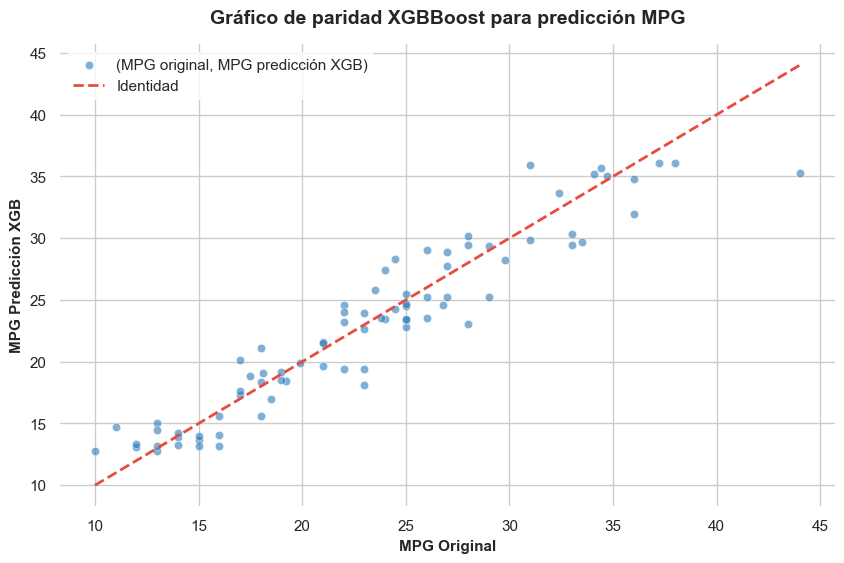

In [36]:
sns.set_theme(style ='whitegrid', context = "notebook")
plt.figure(figsize=(10,6))
plt.scatter(y_test,
            Y_pred_xgb,
            color = '#2b7bba',
            alpha = 0.6,
            edgecolors='w',
            linewidths=0.5,
            label='(MPG original, MPG predicción XGB)')
plt.plot(
       [y_test.min(), y_test.max()],
    [y_test.min(), y_test.max()],
    color = '#e74c3c',
    linestyle = '--',
    linewidth = 2,
    label = 'Identidad'
)
plt.title('Gráfico de paridad XGBBoost para predicción MPG', fontsize =14, fontweight ='bold',pad=15)
plt.xlabel('MPG Original', fontsize = 11, fontweight='semibold')
plt.ylabel('MPG Predicción XGB', fontsize =11, fontweight='semibold')
plt.legend(frameon = True, facecolor='white', edgecolor='none')
sns.despine(left = True, bottom = True)
plt.savefig(f'{PROJECT}/figures/prediccion_xgb_base.png',
            bbox_inches='tight')
plt.show()

------------------------------------------------
------------------------------------------------------------------------------------------------

+ **GRID SEARCH PARA XGBOOST**

In [37]:
from sklearn.model_selection import cross_val_score
from sklearn.model_selection import KFold

In [38]:
cross_fold = KFold(n_splits = 5, shuffle=True, random_state=42)

+ Buscaremos hiperparámetros automáticamente  

In [39]:
from sklearn.model_selection import GridSearchCV

+ Definimos la rejilla de parámetros

In [40]:
#  GridSearchCV — XGBoost 
# Búsqueda de hiperparámetros con validación cruzada.
# Total combinaciones: 64 (antes ~729). Resultado equivalente.
params_XGB = {
    'max_depth' : [3,4,5],
    'learning_rate' : [0.01, 0.05, 0.07],
    'n_estimators' : [200, 300, 400],
    'reg_alpha' : [0.01, 0.03, 0.04],
    'reg_lambda' : [1.0, 3.0, 4.0],
    'gamma' : [0.1, 0.2,0.3],
    #'min_child_weight' : [3, 5, 6]
}

#creamos el modelo

model_XGB = XGBRegressor(
    subsample =0.8,
    colsample_bytree = 0.8,
    random_state=42
)

#ejecutamos el modelo

grid_XGB = GridSearchCV(
    estimator = model_XGB,
    param_grid = params_XGB,
    cv = 5,
    scoring='r2',
    n_jobs = -1
)


grid_XGB.fit(X_train, y_train)

,"estimator estimator: estimator objectThis is assumed to implement the scikit-learn estimator interface.Either estimator needs to provide a ``score`` function,or ``scoring`` must be passed.","XGBRegressor(...ree=None, ...)"
,"param_grid param_grid: dict or list of dictionariesDictionary with parameters names (`str`) as keys and lists ofparameter settings to try as values, or a list of suchdictionaries, in which case the grids spanned by each dictionaryin the list are explored. This enables searching over any sequenceof parameter settings.","{'gamma': [0.1, 0.2, ...], 'learning_rate': [0.01, 0.05, ...], 'max_depth': [3, 4, ...], 'n_estimators': [200, 300, ...], ...}"
,"scoring scoring: str, callable, list, tuple or dict, default=NoneStrategy to evaluate the performance of the cross-validated model onthe test set.If `scoring` represents a single score, one can use:- a single string (see :ref:`scoring_string_names`);- a callable (see :ref:`scoring_callable`) that returns a single value;- `None`, the `estimator`'s :ref:`default evaluation criterion <scoring_api_overview>` is used.If `scoring` represents multiple scores, one can use:- a list or tuple of unique strings;- a callable returning a dictionary where the keys are the metric names and the values are the metric scores;- a dictionary with metric names as keys and callables as values.See :ref:`multimetric_grid_search` for an example.",'r2'
,"n_jobs n_jobs: int, default=NoneNumber of jobs to run in parallel.``None`` means 1 unless in a :obj:`joblib.parallel_backend` context.``-1`` means using all processors. See :term:`Glossary <n_jobs>`for more details... versionchanged:: v0.20 `n_jobs` default changed from 1 to None",-1
,"cv cv: int, cross-validation generator or an iterable, default=NoneDetermines the cross-validation splitting strategy.Possible inputs for cv are:- None, to use the default 5-fold cross validation,- integer, to specify the number of folds in a `(Stratified)KFold`,- :term:`CV splitter`,- an iterable yielding (train, test) splits as arrays of indices.For integer/None inputs, if the estimator is a classifier and ``y`` iseither binary or multiclass, :class:`StratifiedKFold` is used. In allother cases, :class:`KFold` is used. These splitters are instantiatedwith `shuffle=False` so the splits will be the same across calls.Refer :ref:`User Guide <cross_validation>` for the variouscross-validation strategies that can be used here... versionchanged:: 0.22 ``cv`` default value if None changed from 3-fold to 5-fold.",5
,"refit refit: bool, str, or callable, default=TrueRefit an estimator using the best found parameters on the wholedataset.For multiple metric evaluation, this needs to be a `str` denoting thescorer that would be used to find the best parameters for refittingthe estimator at the end.Where there are considerations other than maximum score inchoosing a best estimator, ``refit`` can be set to a function whichreturns the selected ``best_index_`` given ``cv_results_``. In thatcase, the ``best_estimator_`` and ``best_params_`` will be setaccording to the returned ``best_index_`` while the ``best_score_``attribute will not be available.The refitted estimator is made available at the ``best_estimator_``attribute and permits using ``predict`` directly on this``GridSearchCV`` instance.Also for multiple metric evaluation, the attributes ``best_index_``,``best_score_`` and ``best_params_`` will only be available if``refit`` is set and all of them will be determined w.r.t this specificscorer.See ``scoring`` parameter to know more about multiple metricevaluation.See :ref:`sphx_glr_auto_examples_model_selection_plot_grid_search_digits.py`to see how to design a custom selection strategy using a callablevia `refit`.See :ref:`this example<sphx_glr_auto_examples_model_selection_plot_grid_search_refit_callable.py>`for an example of how to use ``refit=callable`` to balance modelcomplexity and cross-validated score... versionchanged:: 0.20 Support for callable added.",True
,"v

+ vemos los mejores parámtros

In [41]:
print(grid_XGB.best_params_)

{'gamma': 0.1, 'learning_rate': 0.07, 'max_depth': 3, 'n_estimators': 200, 'reg_alpha': 0.03, 'reg_lambda': 4.0}


+ entrenamos el mejor modelo

In [42]:
best_xgb_grid = grid_XGB.best_estimator_

+ veamos sus parámetros

In [43]:
print(best_xgb_grid)


XGBRegressor(base_score=None, booster=None, callbacks=None,
             colsample_bylevel=None, colsample_bynode=None,
             colsample_bytree=0.8, device=None, early_stopping_rounds=None,
             enable_categorical=True, eval_metric=None, feature_types=None,
             feature_weights=None, gamma=0.1, grow_policy=None,
             importance_type=None, interaction_constraints=None,
             learning_rate=0.07, max_bin=None, max_cat_threshold=None,
             max_cat_to_onehot=None, max_delta_step=None, max_depth=3,
             max_leaves=None, min_child_weight=None, missing=nan,
             monotone_constraints=None, multi_strategy=None, n_estimators=200,
             n_jobs=None, num_parallel_tree=None, ...)


+ Vamos a hacer predicciones y evaluar las métricas

In [44]:
y_pred_XGB_grid = best_xgb_grid.predict(X_test)

mse_grid = mean_squared_error(y_test, y_pred_XGB_grid)
rmse_grid = mse_grid**0.5
mae_grid = mean_absolute_error(y_test, y_pred_XGB_grid)
r2_grid = r2_score(y_test, y_pred_XGB_grid)

print(f'RMSE: {rmse_grid}')
#print(f'MSE: {mse_grid}')
print(f'MAE: {mae_grid}')
print(f'R^2: {r2_grid}')

RMSE: 2.3529109682484175
MAE: 1.7753808784484868
R^2: 0.8970326166587184


+ Visualización de XGB mediante grid search

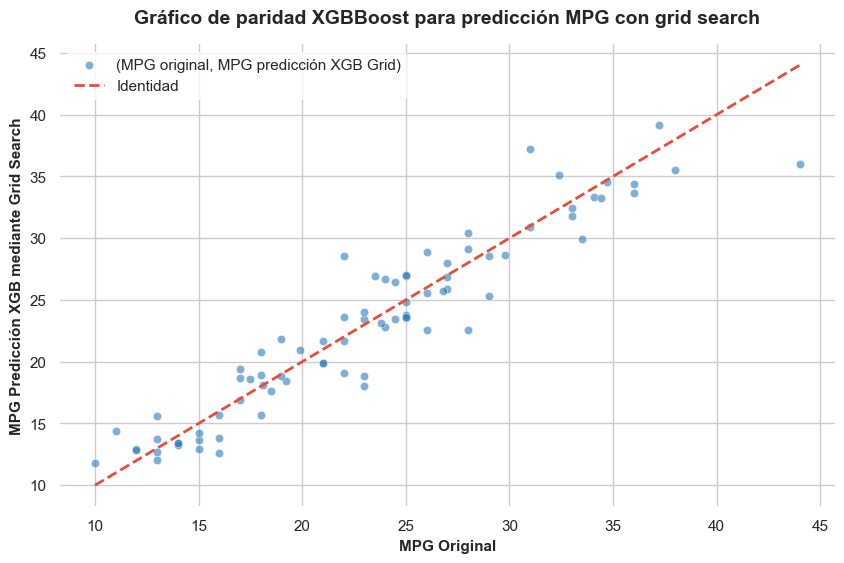

In [45]:
sns.set_theme(style='whitegrid', context="notebook")
plt.figure(figsize=(10,6))
plt.scatter(y_test,
            y_pred_XGB_grid,
            color='#2b7bba',
            alpha=0.6,
            edgecolors='w',
            linewidths=0.5,
            label='(MPG original, MPG predicción XGB Grid)')
plt.plot(
       [y_test.min(), y_test.max()],
    [y_test.min(), y_test.max()],
    color='#e74c3c',
    linestyle='--',
    linewidth=2,
    label='Identidad'
)
plt.title('Gráfico de paridad XGBBoost para predicción MPG con grid search', fontsize =14, fontweight ='bold',pad=15)
plt.xlabel('MPG Original', fontsize =11, fontweight='semibold')
plt.ylabel('MPG Predicción XGB mediante Grid Search', fontsize =11, fontweight='semibold')
plt.legend(frameon=True, facecolor='white', edgecolor='none')
sns.despine(left=True, bottom=True)
plt.savefig(f'{PROJECT}/figures/Prediccion_XGB_GS',
            bbox_inches='tight')
plt.show()

------------------------------------------------
------------------------------------------------
------------------------------------------------
**GRID SEARCH PARA ADABOOST**

+ La idea al hacer gridsearch con adaboost es la misma que para xgboost

+ Ya habiamos definido un arbol base y un modelo __ADA__

Definimos la rejilla de parámetros

In [46]:
param_grid_ADA = {
    'estimator__max_depth' : [3,4,5],
    'n_estimators' : [200, 300, 400],
    'learning_rate' : [0.02, 0.04, 0.05],
    'loss' : ['linear', 'square']
}

+ Ya habíamos definido el cross fold y el modelo ADA

In [47]:
grid_ADA = GridSearchCV(
    estimator = ADA,
    param_grid = param_grid_ADA,
    cv = cross_fold,
    scoring = 'r2',
    n_jobs = -1
)

+ Entrenamos el modelo

In [48]:
grid_ADA.fit(X_train, y_train) 

,"estimator estimator: estimator objectThis is assumed to implement the scikit-learn estimator interface.Either estimator needs to provide a ``score`` function,or ``scoring`` must be passed.",AdaBoostRegre...ndom_state=42)
,"param_grid param_grid: dict or list of dictionariesDictionary with parameters names (`str`) as keys and lists ofparameter settings to try as values, or a list of suchdictionaries, in which case the grids spanned by each dictionaryin the list are explored. This enables searching over any sequenceof parameter settings.","{'estimator__max_depth': [3, 4, ...], 'learning_rate': [0.02, 0.04, ...], 'loss': ['linear', 'square'], 'n_estimators': [200, 300, ...]}"
,"scoring scoring: str, callable, list, tuple or dict, default=NoneStrategy to evaluate the performance of the cross-validated model onthe test set.If `scoring` represents a single score, one can use:- a single string (see :ref:`scoring_string_names`);- a callable (see :ref:`scoring_callable`) that returns a single value;- `None`, the `estimator`'s :ref:`default evaluation criterion <scoring_api_overview>` is used.If `scoring` represents multiple scores, one can use:- a list or tuple of unique strings;- a callable returning a dictionary where the keys are the metric names and the values are the metric scores;- a dictionary with metric names as keys and callables as values.See :ref:`multimetric_grid_search` for an example.",'r2'
,"n_jobs n_jobs: int, default=NoneNumber of jobs to run in parallel.``None`` means 1 unless in a :obj:`joblib.parallel_backend` context.``-1`` means using all processors. See :term:`Glossary <n_jobs>`for more details... versionchanged:: v0.20 `n_jobs` default changed from 1 to None",-1
,"cv cv: int, cross-validation generator or an iterable, default=NoneDetermines the cross-validation splitting strategy.Possible inputs for cv are:- None, to use the default 5-fold cross validation,- integer, to specify the number of folds in a `(Stratified)KFold`,- :term:`CV splitter`,- an iterable yielding (train, test) splits as arrays of indices.For integer/None inputs, if the estimator is a classifier and ``y`` iseither binary or multiclass, :class:`StratifiedKFold` is used. In allother cases, :class:`KFold` is used. These splitters are instantiatedwith `shuffle=False` so the splits will be the same across calls.Refer :ref:`User Guide <cross_validation>` for the variouscross-validation strategies that can be used here... versionchanged:: 0.22 ``cv`` default value if None changed from 3-fold to 5-fold.",KFold(n_split... shuffle=True)
,"refit refit: bool, str, or callable, default=TrueRefit an estimator using the best found parameters on the wholedataset.For multiple metric evaluation, this needs to be a `str` denoting thescorer that would be used to find the best parameters for refittingthe estimator at the end.Where there are considerations other than maximum score inchoosing a best estimator, ``refit`` can be set to a function whichreturns the selected ``best_index_`` given ``cv_results_``. In thatcase, the ``best_estimator_`` and ``best_params_`` will be setaccording to the returned ``best_index_`` while the ``best_score_``attribute will not be available.The refitted estimator is made available at the ``best_estimator_``attribute and permits using ``predict`` directly on this``GridSearchCV`` instance.Also for multiple metric evaluation, the attributes ``best_index_``,``best_score_`` and ``best_params_`` will only be available if``refit`` is set and all of them will be determined w.r.t this specificscorer.See ``scoring`` parameter to know more about multiple metricevaluation.See :ref:`sphx_glr_auto_examples_model_selection_plot_grid_search_digits.py`to see how to design a custom selection strategy using a callablevia `refit`.See :ref:`this example<sphx_glr_auto_examples_model_selection_plot_grid_search_refit_callable.py>`for an example of how to use ``refit=callable`` to balance modelcomplexity and cross-validated score... versionchanged:: 0.20 

In [49]:
print(grid_ADA.best_params_)

best_ADA_grid = grid_ADA.best_estimator_

{'estimator__max_depth': 5, 'learning_rate': 0.05, 'loss': 'linear', 'n_estimators': 400}


+ Recuperamos el modelo con mejores parámetros segun el grid search

In [50]:

pred_ADA_grid = best_ADA_grid.predict(X_test)

+ Calculo de las métricas

In [51]:
#y_pred_ADA_grid = best_ADA_grid.predict(X_test)

mse_grid_ada = mean_squared_error(y_test, pred_ADA_grid)
rmse_grid_ada = mse_grid_ada**0.5
mae_grid_ada = mean_absolute_error(y_test, pred_ADA_grid)
r2_grid_ada = r2_score(y_test, pred_ADA_grid)

print(f'RMSE: {rmse_grid_ada}')
#print(f'MSE: {mse_grid_ada}')
print(f'MAE: {mae_grid_ada}')
print(f'R^2: {r2_grid_ada}')

RMSE: 2.25828245578448
MAE: 1.657355286568525
R^2: 0.9051482803323033


+ Visualización de AdaBoost mediante Cross Validation

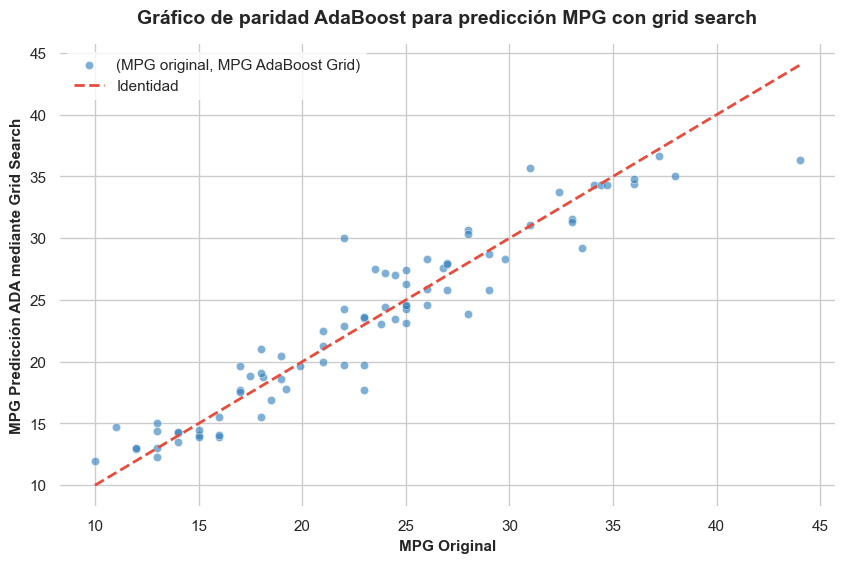

In [52]:
sns.set_theme(style='whitegrid', context="notebook")
plt.figure(figsize=(10,6))
plt.scatter(y_test,
            pred_ADA_grid,
            color='#2b7bba',
            alpha=0.6,
            edgecolors='w',
            linewidths=0.5,
            label='(MPG original, MPG AdaBoost Grid)')
plt.plot(
       [y_test.min(), y_test.max()],
    [y_test.min(), y_test.max()],
    color='#e74c3c',
    linestyle='--',
    linewidth=2,
    label='Identidad'
)
plt.title('Gráfico de paridad AdaBoost para predicción MPG con grid search', fontsize =14, fontweight ='bold',pad=15)
plt.xlabel('MPG Original', fontsize=11, fontweight='semibold')
plt.ylabel('MPG Predicción ADA mediante Grid Search', fontsize=11, fontweight='semibold')
plt.legend(frameon=True, facecolor='white', edgecolor='none')
sns.despine(left=True, bottom=True)
plt.savefig(f'{PROJECT}/figures/Prediccion_ADA',
            bbox_inches='tight')
plt.show()

+ Importancia de Features según cada modelo


In [53]:
# creamos un DF con las importancias de AdaBoost

dfAda_features_imp = pd.DataFrame({
    'feature' : X_train.columns,
    'importance' : best_ADA_grid.feature_importances_
}).sort_values(by = 'importance', ascending = False)

#creamos un df con las importancias de XGBoost

dfXGB_features_imp = pd.DataFrame({
    'feature' : X_train.columns,
    'importance' : best_xgb_grid.feature_importances_
}).sort_values(by = 'importance', ascending = False)


+ Graficación de importance features

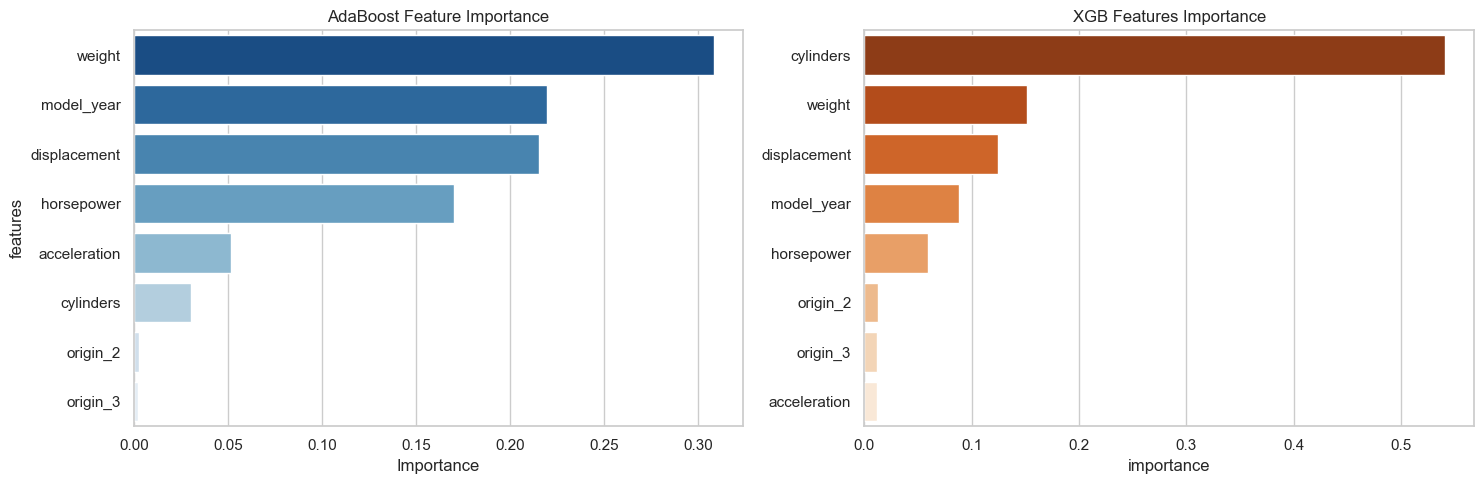

In [54]:
fig, axes = plt.subplots(nrows = 1, ncols = 2, figsize = (15, 5))

#graf para Ada
sns.barplot(x = 'importance', y = 'feature', hue = 'feature', data = dfAda_features_imp, ax = axes[0], palette='Blues_r')
axes[0].set_title('AdaBoost Feature Importance')
axes[0].set_xlabel('Importance')
axes[0].set_ylabel('features')

#graf para XGB
sns.barplot(x = 'importance', y = 'feature', hue= 'feature', data = dfXGB_features_imp, ax=axes[1], palette = 'Oranges_r')
axes[1].set_title('XGB Features Importance')
axes[1].set_xlabel('importance')
axes[1].set_ylabel('')

#graf para ada por cross validation
sns.barplot(x = 'importance', y = 'feature', hue = 'feature', data = dfAda_features_imp, ax = axes[0], palette='Blues_r')
axes[0].set_title('AdaBoost Feature Importance')
axes[0].set_xlabel('Importance')
axes[0].set_ylabel('features')


#plot
plt.tight_layout()
plt.savefig(f'{PROJECT}/figures/importancias_ADA_XGB.png',
            bbox_inches='tight')
plt.show()

Las importancias de las features evaluadas por AdaBoost y por XGB son diferentes. Sin embargo, las variables con mayor importancia, elegidas por cada modelo, parecen estar dentro de la lógica del problema, pues un mayor peso requerirá mayor consumo de combustible, así como un mayor cilindraje, requerirá un mayor consumo.

+ La diferencia en la evaluación del nivel de importancia es normal:

+ *AdaBoost* calcula la importancia usando el coeficiente ´gini importance´ o el ´mean decrece in impurity (MDI)´. Mide qué tanto ayudan las características a purificar los nodos de los árboles de decisión que se van creando.

+ *XGBoost* utiliza el coeficiente ´gain´ y mide la meora relatica en la precisión que aporta cada caracterísitica al ser introducida en las ramas del árbol.


+ Hagamos una comparación de los resultados obtenidos con cada modelo:


In [55]:
evaluacion = pd.DataFrame({
    "modelo" : ["AdaBoost", "XGBoost", "AdaBoost GS", "XGB GS"],
    "MSE" : [mse_ADA, mse_xgb, mse_grid_ada, mse_grid],
    "RMSE" : [rmse_ADA, rmse_xgb, rmse_grid_ada, rmse_grid],
    "MAE" : [mae_ADA, mae_xgb, mae_grid_ada, mae_grid],
    "R^2" : [r2_ADA, r2_xgb, r2_grid_ada, r2_grid]
})
print(evaluacion)

        modelo       MSE      RMSE       MAE       R^2
0     AdaBoost  5.865233  2.421824  1.721289  0.890913
1      XGBoost  5.277493  2.297279  1.755098  0.901844
2  AdaBoost GS  5.099840  2.258282  1.657355  0.905148
3       XGB GS  5.536190  2.352911  1.775381  0.897033


+ Al implementar hiperparámetros ajustados según el tipo de problema tratado, encontramos una mejoría en XGB respecto a ADA. Los parámetros clave incorporados en esta mejoría fueron *reg_alpha=0.1*, *reg_lambda = 1.0*, *gamma=1.0* y *min_child_weight = 5*. Al incorporar estos hiperparámetros en XGB, los coeficientes de evaluación mejoraron y son similares a los obtenidos con ADA.

* Por ultimo, guardamos las metricas finales en un csv

In [56]:
# Guardar métricas 
evaluacion.to_csv(os.path.join(DATA, 'metricas_boosting.csv'), index=False)

# Verificar guardado
import os
print("Archivos en data/:")
for a in sorted(os.listdir(DATA)):
    if not a.startswith('.'):
        print(f"  - {a}")

Archivos en data/:
  - auto_mpg_clean.csv
  - auto_mpg_clean.xlsx
  - metricas_boosting.csv
  - metricas_rf.csv
  - scaler.pkl
  - test_raw.csv
  - test_scaled.csv
  - train_raw.csv
  - train_scaled.csv


**errores AdaBoost**

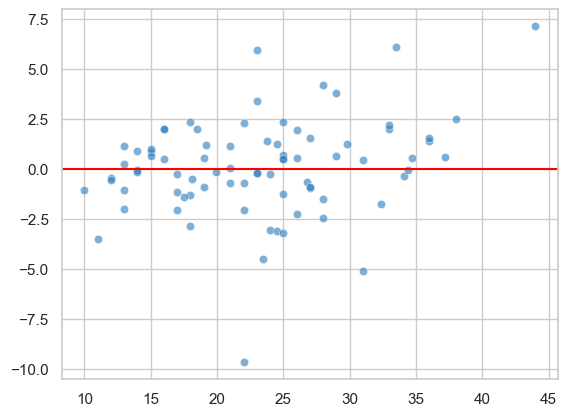

In [57]:
errores_ada = y_test - y_pred_ada
plt.scatter(y_test, errores_ada, color = '#2b7bba', alpha = 0.6, edgecolors = 'w', linewidths = 0.5)
plt.axhline(0, color='red')

**errores con GridSearch AdaBoost**

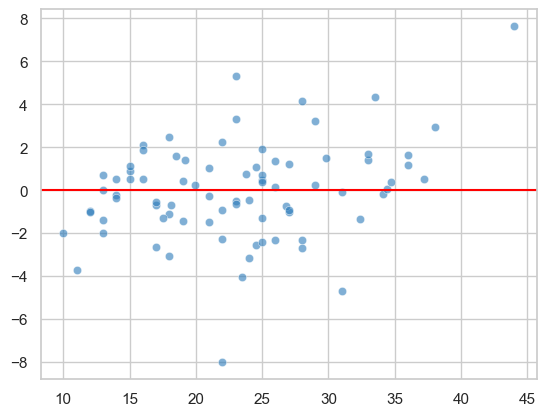

In [58]:
errores_ada_grid = y_test - pred_ADA_grid
plt.scatter(y_test, errores_ada_grid, color = '#2b7bba', alpha = 0.6, edgecolors = 'w', linewidths = 0.5)
plt.axhline(0, color='red')

**Errores con XGBoost**

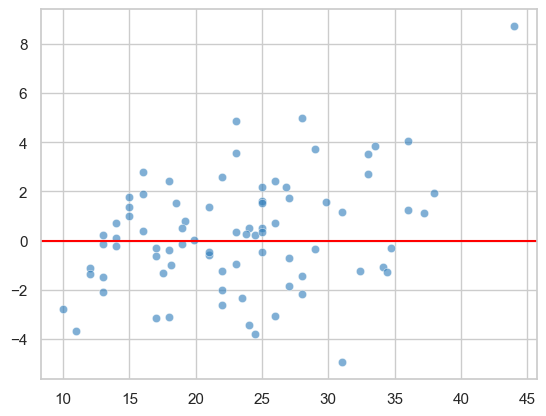

In [59]:
errores_xgb = y_test - Y_pred_xgb
plt.scatter(y_test, errores_xgb, color = '#2b7bba', alpha = 0.6, edgecolors = 'w', linewidths = 0.5)
plt.axhline(0, color='red')

**Errores Grid Search con XGB**

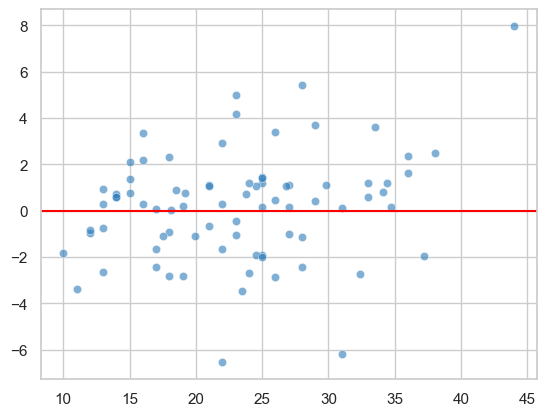

In [60]:
errores_xgb_grid = y_test - y_pred_XGB_grid
plt.scatter(y_test, errores_xgb_grid, color = '#2b7bba', alpha = 0.6, edgecolors = 'w', linewidths = 0.5)
plt.axhline(0, color='red')